## K Means Clustering Algorithm

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
#Taking the data samples from the make_blobs dataset
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
X

array([[-6.95474831,  3.09503178],
       [-5.26138749,  5.13962138],
       [-5.96198952,  4.44433829],
       ...,
       [-4.24698208,  2.46570593],
       [-5.05376917,  3.56520704],
       [ 7.85053321,  8.54240445]])

In [4]:
y

array([1, 1, 1, 2, 2, 0, 2, 2, 2, 2, 2, 0, 0, 1, 1, 2, 2, 2, 2, 0, 2, 2,
       1, 0, 1, 0, 1, 1, 0, 2, 1, 0, 0, 1, 1, 1, 0, 2, 1, 2, 2, 2, 2, 0,
       2, 1, 2, 1, 0, 1, 2, 0, 1, 0, 2, 1, 0, 2, 1, 0, 0, 0, 2, 1, 2, 1,
       2, 0, 0, 0, 1, 0, 2, 2, 2, 0, 0, 0, 1, 2, 2, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 2, 1, 0, 1, 2, 1, 1, 0, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1,
       0, 0, 1, 1, 2, 2, 1, 0, 2, 1, 2, 0, 1, 2, 0, 1, 0, 0, 2, 2, 2, 0,
       1, 1, 0, 0, 0, 2, 1, 1, 0, 2, 0, 2, 2, 2, 2, 0, 2, 0, 0, 0, 1, 1,
       2, 2, 2, 0, 1, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 0, 2,
       2, 1, 0, 0, 2, 2, 1, 1, 1, 1, 1, 0, 2, 0, 0, 1, 2, 0, 1, 2, 2, 1,
       2, 0, 0, 1, 0, 2, 2, 2, 2, 1, 0, 1, 1, 0, 0, 1, 2, 2, 0, 1, 0, 2,
       2, 2, 0, 2, 0, 2, 1, 1, 1, 0, 0, 0, 2, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 2, 0, 1, 2, 0, 2, 1, 1, 0, 1, 1, 2, 0, 2, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 2, 2, 2, 1, 1, 0, 0, 0, 0, 1, 2, 0, 1, 1, 2, 2, 1, 1,
       2, 1, 1, 0, 0, 0, 0, 1, 2, 2, 2, 2, 1, 1, 0,

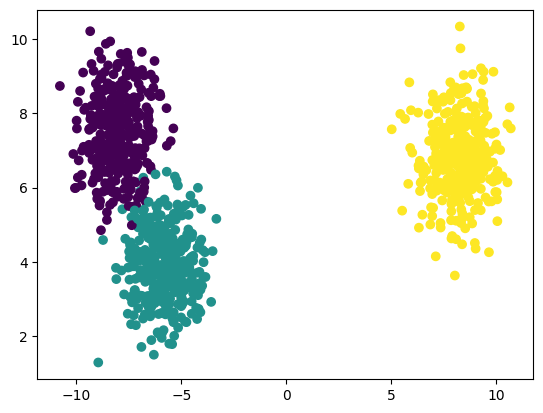

In [5]:
plt.scatter(X[:,0],X[:,1], c=y)

In [6]:
## standardization -> feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [9]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [10]:
from sklearn.cluster import KMeans

In [11]:
#Elbow method to select k value

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [12]:
wcss

[1340.0000000000002,
 632.135730236954,
 202.1529316682112,
 147.281019798315,
 105.29591322706239,
 75.49376756340574,
 98.08090238311102,
 53.50541393694448,
 43.93967264221442,
 39.90335540669135]

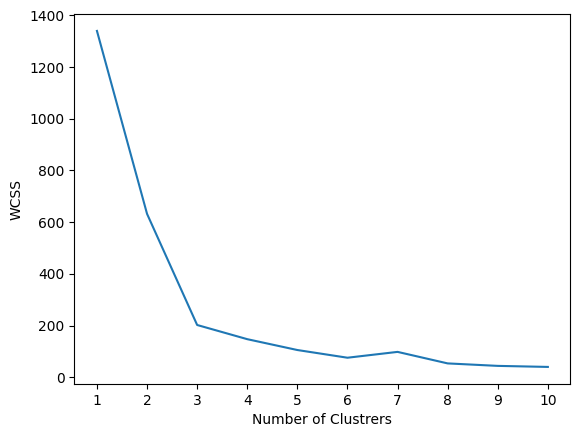

In [13]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [14]:
 kmeans=KMeans(n_clusters=3,init="k-means++")

In [15]:
kmeans.fit_predict(X_train_scaled)

array([1, 2, 2, 1, 0, 2, 2, 2, 0, 1, 2, 0, 1, 0, 1, 1, 0, 1, 2, 0, 1, 2,
       0, 2, 2, 0, 0, 1, 1, 1, 0, 2, 0, 0, 1, 2, 2, 2, 0, 1, 1, 0, 2, 0,
       1, 1, 0, 1, 1, 1, 2, 1, 0, 2, 1, 0, 1, 0, 0, 0, 0, 1, 2, 1, 0, 2,
       0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 0, 2, 0, 2, 0, 0, 2,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 2, 1, 0, 0, 2, 2, 1, 1, 2, 0, 2, 1, 1,
       1, 0, 0, 2, 1, 1, 2, 1, 1, 2, 1, 0, 2, 2, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 2, 1, 2, 1, 0, 2, 1, 1, 2, 2, 0, 2, 0, 0, 2, 2, 2, 2, 0,
       0, 2, 1, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 2, 0, 0, 2, 0, 2,
       1, 0, 0, 2, 2, 2, 1, 1, 0, 1, 2, 2, 0, 0, 1, 1, 2, 2, 1, 2, 0, 1,
       1, 0, 1, 2, 0, 0, 1, 2, 0, 2, 0, 1, 1, 0, 0, 2, 0, 0, 2, 1, 0, 2,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 2, 2, 1, 2, 0, 2, 2,
       1, 1, 2, 2, 2, 1, 2, 1, 1, 2, 2, 0, 2, 2, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 2, 1, 0, 0, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 2,
       1, 2, 2, 0, 0, 2, 1, 0, 1, 0, 2, 0, 0, 1, 0,

In [16]:
y_pred=kmeans.predict(X_test_scaled)

In [17]:
y_pred

array([1, 0, 2, 0, 2, 0, 1, 0, 0, 2, 0, 2, 2, 1, 0, 2, 0, 1, 1, 0, 1, 2,
       1, 1, 0, 0, 2, 2, 1, 0, 2, 0, 0, 0, 2, 1, 2, 0, 2, 2, 1, 1, 2, 2,
       0, 0, 1, 0, 1, 2, 0, 1, 0, 1, 2, 0, 1, 1, 1, 0, 1, 1, 1, 0, 2, 1,
       2, 1, 0, 2, 2, 0, 2, 0, 2, 2, 0, 1, 0, 1, 1, 1, 2, 2, 2, 1, 0, 2,
       1, 1, 2, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 2, 2, 1, 1, 1, 2, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 2, 2, 1, 0, 0, 1, 0, 0, 1, 2, 2, 0, 1, 0, 2,
       0, 0, 2, 0, 1, 1, 2, 1, 1, 0, 2, 0, 0, 0, 2, 2, 1, 0, 2, 0, 2, 0,
       0, 0, 2, 2, 2, 1, 0, 0, 1, 2, 1, 2, 2, 0, 1, 2, 2, 0, 2, 2, 2, 0,
       0, 2, 1, 1, 0, 1, 2, 1, 0, 1, 1, 0, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       1, 0, 1, 2, 0, 2, 2, 1, 0, 0, 1, 0, 0, 1, 2, 0, 1, 2, 1, 2, 0, 2,
       2, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 1, 2, 1, 1,
       2, 1, 1, 0, 0, 2, 2, 1, 2, 1, 0, 1, 1, 2, 1, 2, 0, 2, 1, 1, 0, 2,
       2, 1, 0, 0, 0, 2, 1, 1, 2, 1, 1, 1, 1, 0, 2, 2, 2, 2, 0, 2, 2, 1,
       2, 1, 0, 1, 1, 1, 2, 2, 0, 1, 1, 2, 1, 1, 1,

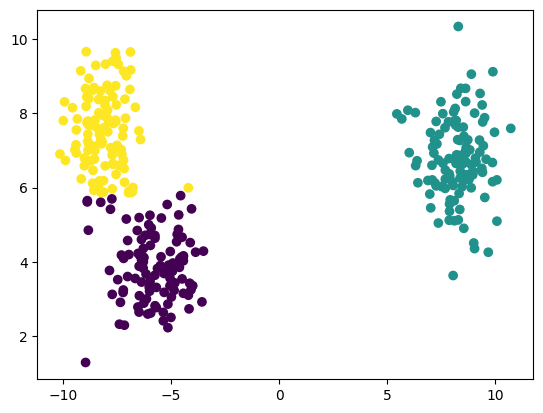

In [18]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [23]:
#Validating the K value 
#kneelocator , Siljhoutee scoring
import sys
!"{sys.executable}" -m pip install kneed

In [24]:
from kneed import KneeLocator

In [31]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
print("Optimal k:", kl.knee)

Optimal k: 3


In [26]:
kl.elbow

3

In [32]:
## silhoutte score
from sklearn.metrics import silhouette_score
score = silhouette_score(X_test_scaled, y_pred)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.658


In [33]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [34]:
silhouette_coefficients

[0.5599138412605342,
 0.6627267139958862,
 0.5814222272662299,
 0.5116039073238677,
 0.4875571117339452,
 0.45222483105955075,
 0.461263601090732,
 0.42925887914662225,
 0.4249278006678039]

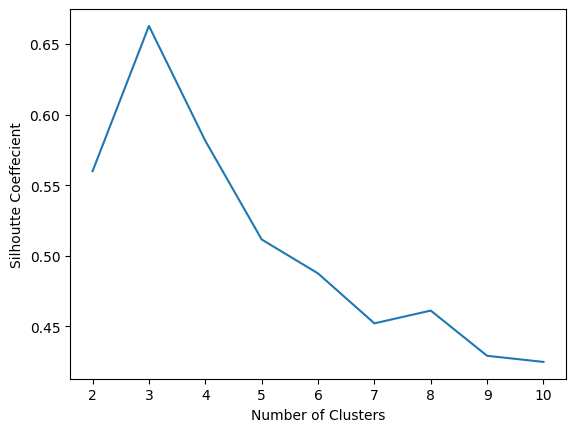

In [36]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()